# Financial Inclusion — Baseline Model

---

**Ziel:** Erstes klassifizierendes Modell für die Vorhersage von `bank_account` (0 = No, 1 = Yes).

**Datengrundlage:** `features_encoded_train.csv` — bereits enkodierte Features aus `Train_Encoding.ipynb`

**Wichtig:** Klassenungleichgewicht — nur ~14% der Einträge haben ein Bankkonto.  
→ Accuracy ist kein sinnvolles Maß. Wir verwenden **ROC-AUC** als Primärmetrik.

| Schritt | Inhalt |
|---|---|
| 1 | Daten laden & verstehen |
| 2 | X / y aufteilen |
| 3 | Stratified Train / Validation Split |
| 4 | Baseline: Logistic Regression |
| 5 | Evaluation: ROC-AUC, Confusion Matrix, Classification Report |
| 6 | Feature Importance (Koeffizienten) |
| 7 | Predictions auf Test-Daten & Submission-Datei |

---
## Step 0 — Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

RANDOM_STATE = 42
print('Imports OK')

Imports OK


---
## Step 1 — Daten laden & verstehen

In [14]:
df = pd.read_csv('data/features_encoded_train.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head(3)

Shape: 23,524 rows × 18 columns

Columns: ['age_of_respondent', 'bin_location_type', 'bin_cellphone_access', 'bin_gender', 'ord_education_level', 'ohe_country_Rwanda', 'ohe_country_Tanzania', 'ohe_country_Uganda', 'ohe_job_Farming and Fishing', 'ohe_job_Formally employed Government', 'ohe_job_Formally employed Private', 'ohe_job_Government Dependent', 'ohe_job_Informally employed', 'ohe_job_No Income', 'ohe_job_Other Income', 'ohe_job_Remittance Dependent', 'ohe_job_Self employed', 'target_bank_account']


,age_of_respondent,bin_location_type,bin_cellphone_access,bin_gender,ord_education_level,ohe_country_Rwanda,ohe_country_Tanzania,ohe_country_Uganda,ohe_job_Farming and Fishing,ohe_job_Formally employed Government,ohe_job_Formally employed Private,ohe_job_Government Dependent,ohe_job_Informally employed,ohe_job_No Income,ohe_job_Other Income,ohe_job_Remittance Dependent,ohe_job_Self employed,target_bank_account
0,24,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,1,1
1,70,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,26,1,1,1,3,0,0,0,0,0,0,0,0,0,0,0,1,1


Zielverteilung (target_bank_account):
  No  (0): 20,212  (85.9%)
  Yes (1): 3,312  (14.1%)

→ Klassenungleichgewicht! Wir verwenden class_weight="balanced" und ROC-AUC als Metrik.


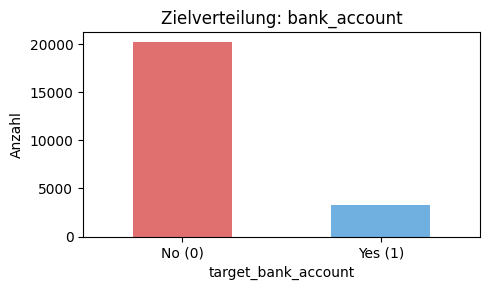

In [15]:
# Klassenverteilung prüfen
vc = df['target_bank_account'].value_counts()
print('Zielverteilung (target_bank_account):')
print(f'  No  (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Yes (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print()
print('→ Klassenungleichgewicht! Wir verwenden class_weight="balanced" und ROC-AUC als Metrik.')

fig, ax = plt.subplots(figsize=(5, 3))
vc.rename({0: 'No (0)', 1: 'Yes (1)'}).plot(kind='bar', ax=ax, color=['#e07070', '#70b0e0'])
ax.set_title('Zielverteilung: bank_account')
ax.set_ylabel('Anzahl')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
## Step 2 — X / y aufteilen

In [16]:
X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

print(f'X shape: {X.shape}  (Features)')
print(f'y shape: {y.shape}  (Target)')
print(f'\nFeature-Spalten ({len(X.columns)}):')
for col in X.columns:
    print(f'  • {col}')

X shape: (23524, 17)  (Features)
y shape: (23524,)  (Target)

Feature-Spalten (17):
  • age_of_respondent
  • bin_location_type
  • bin_cellphone_access
  • bin_gender
  • ord_education_level
  • ohe_country_Rwanda
  • ohe_country_Tanzania
  • ohe_country_Uganda
  • ohe_job_Farming and Fishing
  • ohe_job_Formally employed Government
  • ohe_job_Formally employed Private
  • ohe_job_Government Dependent
  • ohe_job_Informally employed
  • ohe_job_No Income
  • ohe_job_Other Income
  • ohe_job_Remittance Dependent
  • ohe_job_Self employed


---
## Step 3 — Stratified Train / Validation Split

**Stratified** stellt sicher, dass die Klassenverteilung (14% Yes) in beiden Splits gleich ist.

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # wichtig wegen Klassenungleichgewicht
)

print(f'Train set : {X_train.shape[0]:,} Zeilen  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Val set   : {X_val.shape[0]:,} Zeilen  ({X_val.shape[0]/len(X)*100:.0f}%)')
print()
print('Klassenverteilung in y_train:')
print(y_train.value_counts(normalize=True).round(3))
print('Klassenverteilung in y_val:')
print(y_val.value_counts(normalize=True).round(3))

Train set : 18,819 Zeilen  (80%)
Val set   : 4,705 Zeilen  (20%)

Klassenverteilung in y_train:
target_bank_account
0    0.859
1    0.141
Name: proportion, dtype: float64
Klassenverteilung in y_val:
target_bank_account
0    0.859
1    0.141
Name: proportion, dtype: float64


---
## Step 4 — Baseline: Logistic Regression

**Warum Logistic Regression als Baseline?**
- Schnell und interpretierbar
- Gibt Wahrscheinlichkeiten aus (nötig für ROC-AUC)
- `class_weight='balanced'` kompensiert das Klassenungleichgewicht automatisch
- Dient als Referenzpunkt für komplexere Modelle

In [18]:
model = LogisticRegression(
    class_weight='balanced',    # kompensiert 86/14-Split
    max_iter=1000,              # genug Iterationen für Konvergenz
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
print('Modell trainiert.')

Modell trainiert.


---
## Step 5 — Evaluation

In [19]:
# Predictions
y_pred       = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]  # Wahrscheinlichkeit für Klasse 1

# ROC-AUC (Primärmetrik)
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f'ROC-AUC (Validation): {roc_auc:.4f}')
print()

# Classification Report
print('Classification Report:')
print(classification_report(y_val, y_pred, target_names=['No (0)', 'Yes (1)']))

ROC-AUC (Validation): 0.8574

Classification Report:
              precision    recall  f1-score   support

      No (0)       0.95      0.78      0.86      4043
     Yes (1)       0.36      0.76      0.49       662

    accuracy                           0.78      4705
   macro avg       0.66      0.77      0.68      4705
weighted avg       0.87      0.78      0.81      4705



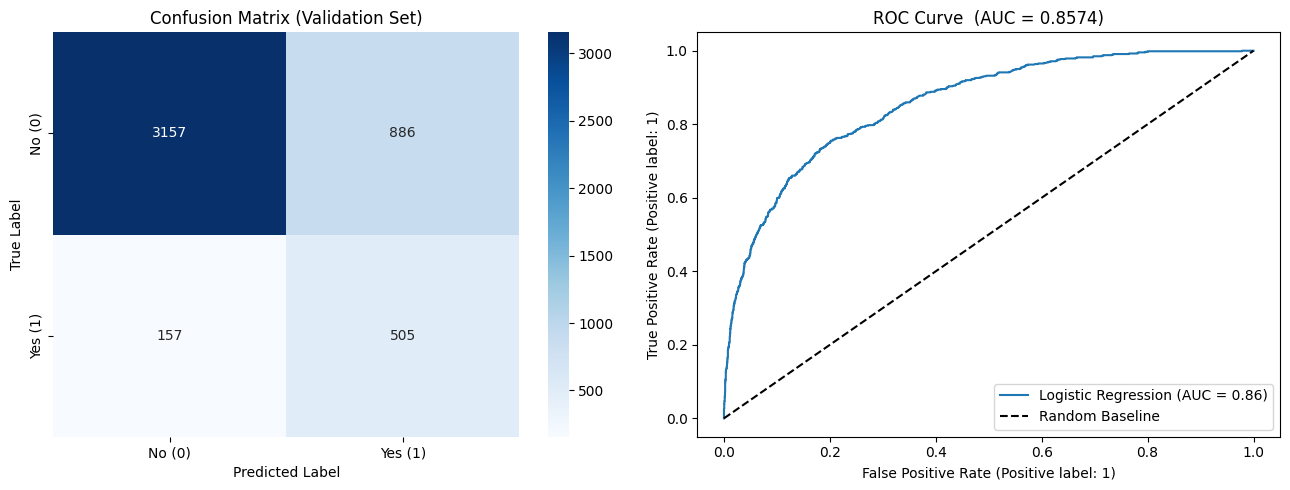

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['No (0)', 'Yes (1)'],
    yticklabels=['No (0)', 'Yes (1)']
)
axes[0].set_title('Confusion Matrix (Validation Set)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_val, y_pred_proba, ax=axes[1], name='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[1].set_title(f'ROC Curve  (AUC = {roc_auc:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 6 — Feature Importance (Koeffizienten)

Bei Logistic Regression zeigt der Betrag des Koeffizienten, wie stark ein Feature zur Entscheidung beiträgt.  
Positiv = erhöht die Wahrscheinlichkeit für "Yes", negativ = verringert sie.

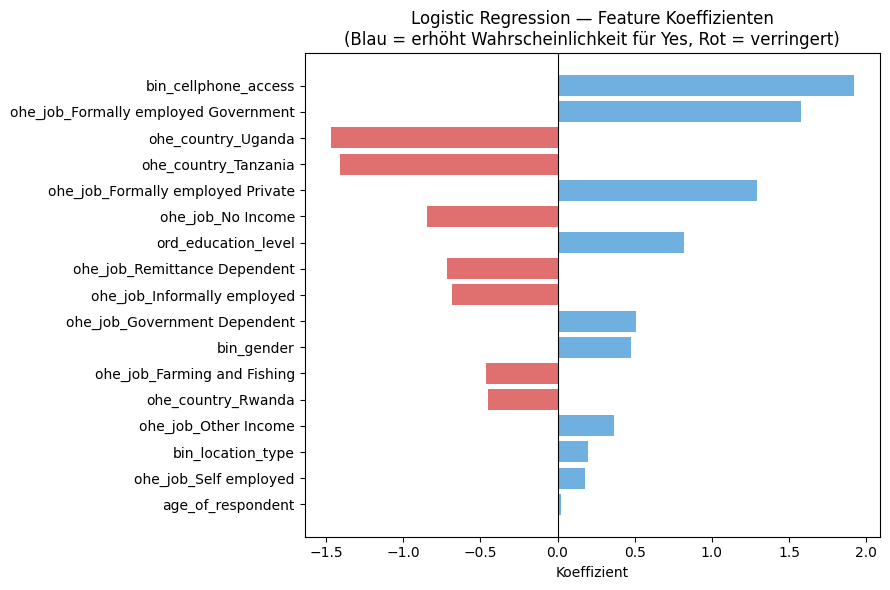

Top 5 wichtigste Features:
                             feature  coefficient
                bin_cellphone_access     1.918934
ohe_job_Formally employed Government     1.574691
                  ohe_country_Uganda    -1.468356
                ohe_country_Tanzania    -1.405311
   ohe_job_Formally employed Private     1.293795


In [21]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e07070' if c < 0 else '#70b0e0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Koeffizienten\n(Blau = erhöht Wahrscheinlichkeit für Yes, Rot = verringert)')
ax.set_xlabel('Koeffizient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 wichtigste Features:')
print(coef_df.head(5).to_string(index=False))

---
## Step  7 — Predictions auf Test-Daten & Submission-Datei

Die Submission erwartet **33.610 Zeilen** — Train (23.524) + Test (10.086).  \n Format der ID: `uniqueid + ' x ' + country`\n\nVorgehen:\n1. Modell auf **allen** Trainingsdaten neu trainieren (kein 80/20-Split)\n2. Predictions für Train-Rows (bekannte Daten) + Test-Rows\n3. IDs zusammenbauen und Submission-Datei befüllen

In [22]:
# Modell auf ALLEN Trainingsdaten neu trainieren (nicht nur 80%)
model_full = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_full.fit(X, y)
print('Modell auf vollständigen Trainingsdaten trainiert.')

# Predictions für Train-Rows
train_proba = model_full.predict_proba(X)[:, 1]

# Predictions für Test-Rows
X_test = pd.read_csv('data/features_encoded_TEST.csv')
test_proba = model_full.predict_proba(X_test)[:, 1]

print(f'Train predictions: {len(train_proba):,}')
print(f'Test  predictions: {len(test_proba):,}')

Modell auf vollständigen Trainingsdaten trainiert.
Train predictions: 23,524
Test  predictions: 10,086


In [23]:
# IDs aus Originaldaten holen: Format "uniqueid x country"
train_raw = pd.read_csv('data/Train.csv')[['uniqueid', 'country']]
test_raw  = pd.read_csv('data/Test.csv')[['uniqueid', 'country']]

train_raw['unique_id'] = train_raw['uniqueid'] + ' x ' + train_raw['country']
test_raw['unique_id']  = test_raw['uniqueid']  + ' x ' + test_raw['country']

# DataFrames mit Predictions bauen
df_train_pred = pd.DataFrame({'unique_id': train_raw['unique_id'].values, 'bank_account': train_proba})
df_test_pred  = pd.DataFrame({'unique_id': test_raw['unique_id'].values,  'bank_account': test_proba})

# Zusammenführen
all_preds = pd.concat([df_train_pred, df_test_pred], ignore_index=True)
print(f'Gesamt-Predictions: {len(all_preds):,}')
all_preds.head(3)

Gesamt-Predictions: 33,610


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.696520
1,uniqueid_2 x Kenya,0.292496
2,uniqueid_3 x Kenya,0.917730


In [24]:
# Submission-Reihenfolge aus SampleSubmission beibehalten
submission = pd.read_csv('data/SampleSubmission.csv')
submission = submission.drop(columns=['bank_account']).merge(all_preds, on='unique_id', how='left')

assert len(submission) == 33610, f'Zeilenzahl falsch: {len(submission)}'
assert submission['bank_account'].isnull().sum() == 0, 'NaN in Predictions!'

output_path = 'submission_baseline_logreg.csv'
submission.to_csv(output_path, index=False)

print(f'Submission gespeichert: {output_path}')
print(f'Zeilen: {len(submission):,}')
print(f'Prediction-Range: {submission["bank_account"].min():.4f} – {submission["bank_account"].max():.4f}')
submission.head()

Submission gespeichert: submission_baseline_logreg.csv
Zeilen: 33,610
Prediction-Range: 0.0054 – 0.9955


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.696520
1,uniqueid_2 x Kenya,0.292496
2,uniqueid_3 x Kenya,0.917730
3,uniqueid_4 x Kenya,0.810459
4,uniqueid_5 x Kenya,0.119213


---
## Zusammenfassung & Nächste Schritte

### Ergebnisse Baseline (Logistic Regression)

| Metrik | Wert |
|---|---|
| ROC-AUC (Validation) | *siehe oben* |

### Nächste Schritte

| Modell | Vorteil | Nächstes Notebook |
|---|---|---|
| Random Forest | Robust, Feature Importance, kein Scaling nötig | `Model_RandomForest.ipynb` |
| LightGBM | Schnell, stark bei tabellarischen Daten | `Model_LightGBM.ipynb` |
| XGBoost | Oft beste Performance bei Klassifikation | `Model_XGBoost.ipynb` |

**Mögliche Verbesserungen:**
- `class_weight` / `scale_pos_weight` tunen
- Hyperparameter-Suche (GridSearchCV / RandomizedSearchCV)
- Cross-Validation statt einfachem Train/Val-Split
- SMOTE / Oversampling der Minderheitsklasse